# Employee Attrition Prediction

## Internship Project - Week 2

### Author
Naman Arora

### Objective
Build a Machine Learning model to predict whether an employee is likely to leave the company based on HR analytics data.

# Task 1 - Data Loading & Exploration

In [40]:
import numpy as numpy
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler


In [41]:
df = pd.read_csv("../WA_Fn-UseC_-HR-Employee-Attrition.csv")

print(df.head(10))
print(df.shape)

# checking how many employees have left the company
print(df["Attrition"].value_counts())

# calculating the percentage of employees who have left the company
attrition_percentage = (df["Attrition"].value_counts()["Yes"] / len(df)) * 100
print(f"Percentage of employees who have left the company: {attrition_percentage:.2f}%")


# printing columns that are numeric 
numeric_columns = df.select_dtypes(include=["int64", "float64"]).columns
print(numeric_columns)

# printing columns that are actegorical 
categorical_columns = df.select_dtypes(include=["object"]).columns
print(categorical_columns)

print(f"Total number of numerical columns: {len(numeric_columns)}")
print(f"Total number of categorical columns: {len(categorical_columns)}")

# observation that we made about the attrition rate 
print("Observation: The attrition rate is relatively low, with only a small percentage of employees leaving the company.\nThis suggests that the company may have a stable work environment and good engagement practices that help retain employees.\nHowever, it is important to further analyze the data to identify any potential factors that may contribute to employee attrition and address them proactively.")

   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   
5   32        No  Travel_Frequently       1005  Research & Development   
6   59        No      Travel_Rarely       1324  Research & Development   
7   30        No      Travel_Rarely       1358  Research & Development   
8   38        No  Travel_Frequently        216  Research & Development   
9   36        No      Travel_Rarely       1299  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8      

/var/folders/1n/1fwqfjps4v5cmtm5yhyw4kmm0000gn/T/ipykernel_3283/604444428.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include=["object"]).columns


### Observation

The dataset is imbalanced because the number of employees who stayed with the company is significantly higher than the number of employees who left. This imbalance should be considered during model training to avoid bias toward the majority class.

# Task 2 - Data Cleaning & Preprocessing

In [42]:
print(df.isnull().sum())

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

### Observation

The dataset contains no missing (null) values in any column. Since all columns have complete data, no missing value treatment such as deletion or imputation is required.

In [43]:
'''
we check constant and identifier columns, standard way   
'''
constant_columns = []

for col in df.columns:
    if df[col].nunique() == 1:
        constant_columns.append(col)

print("Constant Columns:")
print(constant_columns)


identifier_columns = []

for col in df.columns:
    if df[col].nunique() == len(df):
        identifier_columns.append(col)

print("Possible Identifier Columns:")
print(identifier_columns)


# dropping constant and identifier columns
columns_to_drop = constant_columns + identifier_columns

print("Columns to Drop:")
print(columns_to_drop)

df = df.drop(columns=columns_to_drop)

print("Shape before dropping:", (1470, 35))   # or use the shape you noted earlier
print("Shape after dropping:", df.shape)


Constant Columns:
['EmployeeCount', 'Over18', 'StandardHours']
Possible Identifier Columns:
['EmployeeNumber']
Columns to Drop:
['EmployeeCount', 'Over18', 'StandardHours', 'EmployeeNumber']
Shape before dropping: (1470, 35)
Shape after dropping: (1470, 31)


### Observation

The dataset was analyzed to identify columns that do not contribute meaningful information for predicting employee attrition. Constant columns and identifier columns were removed because they provide no useful predictive information and may unnecessarily increase model complexity.

In [44]:
# learnt where to use map practically
df["Attrition"] = df["Attrition"].map({
    "Yes": 1,
    "No": 0
})
print(df["Attrition"].head())

0    1
1    0
2    1
3    0
4    0
Name: Attrition, dtype: int64


### Observation

The target variable was converted from categorical values ("Yes" and "No") to numerical values (1 and 0). This transformation is required because machine learning classification algorithms work with numerical target labels.

In [45]:
columns_to_drop=df.select_dtypes(include=["object"]).columns

df=pd.get_dummies(df, columns=columns_to_drop, drop_first=True)
print(df.head(10))

print(df.shape)

   Age  Attrition  DailyRate  DistanceFromHome  Education  \
0   41          1       1102                 1          2   
1   49          0        279                 8          1   
2   37          1       1373                 2          2   
3   33          0       1392                 3          4   
4   27          0        591                 2          1   
5   32          0       1005                 2          2   
6   59          0       1324                 3          3   
7   30          0       1358                24          1   
8   38          0        216                23          3   
9   36          0       1299                27          3   

   EnvironmentSatisfaction  HourlyRate  JobInvolvement  JobLevel  \
0                        2          94               3         2   
1                        3          61               2         2   
2                        4          92               2         1   
3                        4          56               3  

/var/folders/1n/1fwqfjps4v5cmtm5yhyw4kmm0000gn/T/ipykernel_3283/3941537351.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columns_to_drop=df.select_dtypes(include=["object"]).columns


### Observation

All categorical features were converted into numerical features using One-Hot Encoding. This transformation enables machine learning algorithms to process categorical information without introducing artificial ordering between categories. The `drop_first=True` parameter was used to avoid redundant features.

In [46]:
# axis=1 tells that we need to think horizontally and it is a value in a column not the column name itself
df1=df.drop("Attrition",axis=1) 
df2=df["Attrition"]

numeric_columns=df1.select_dtypes(include=["int64", "float64"]).columns

df1[numeric_columns]=StandardScaler().fit_transform(df1[numeric_columns])

print(df1.head(10))



        Age  DailyRate  DistanceFromHome  Education  EnvironmentSatisfaction  \
0  0.446350   0.742527         -1.010909  -0.891688                -0.660531   
1  1.322365  -1.297775         -0.147150  -1.868426                 0.254625   
2  0.008343   1.414363         -0.887515  -0.891688                 1.169781   
3 -0.429664   1.461466         -0.764121   1.061787                 1.169781   
4 -1.086676  -0.524295         -0.887515  -1.868426                -1.575686   
5 -0.539166   0.502054         -0.887515  -0.891688                 1.169781   
6  2.417384   1.292887         -0.764121   0.085049                 0.254625   
7 -0.758170   1.377177          1.827158  -1.868426                 1.169781   
8  0.117845  -1.453958          1.703764   0.085049                 1.169781   
9 -0.101159   1.230910          2.197341   0.085049                 0.254625   

   HourlyRate  JobInvolvement  JobLevel  JobSatisfaction  MonthlyIncome  ...  \
0    1.383138        0.379672 -0.057788

### Observation

The continuous numerical features were standardized using StandardScaler. Standardization ensures that features with larger numerical ranges do not dominate the learning process of machine learning algorithms. The target variable was kept separate and was not scaled.

# Task 3 - Exploratory Data Analysis (EDA)

In [47]:
# checking the columns as we did some preprocessing so original columns got encode
print(df.columns)

Index(['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education',
       'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel',
       'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager',
       'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely',
       'Department_Research & Development', 'Department_Sales',
       'EducationField_Life Sciences', 'EducationField_Marketing',
       'EducationField_Medical', 'EducationField_Other',
       'EducationField_Technical Degree', 'Gender_Male',
       'JobRole_Human Resources', 'JobRole_Laboratory Technician',
       'JobRole_Manager', 'JobRole_Manufacturing Director',
       'JobRole_Research Director', 'JobRole_Res

In [48]:
# Create a fresh copy of the original dataset for EDA
df_eda = pd.read_csv("../WA_Fn-UseC_-HR-Employee-Attrition.csv")

# just checking the shape of the dataset for EDA
df_eda.shape

(1470, 35)

In [49]:
# DROPPING THE ALREADY FOUND IRRELEVANT COLUMNS FROM THE DF_EDA DATASET 
df_eda = df_eda.drop(
    columns=[
        "EmployeeCount",
        "EmployeeNumber",
        "Over18",
        "StandardHours"
    ]
)
# VERIFYING 
df_eda.shape


(1470, 31)

In [50]:
# Point1 - Attrition rate by Department — which department loses the most employees
department_attrition = (
    df_eda.groupby("Department")["Attrition"]
          .apply(lambda x: (x == "Yes").mean() * 100) # remember that to use lamda x like this 
          .sort_values(ascending=False)
)
highest_attrition_department = (df_eda.groupby("Department")["Attrition"]
                                .apply(lambda x: (x == "Yes").mean() * 100) 
                                .sort_values(ascending=False)[:1]
)

print(f"Departments according to attrition rate:\n{department_attrition}\n")
print(f"Column with the highest attrition rate: {highest_attrition_department}")

Departments according to attrition rate:
Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: Attrition, dtype: float64

Column with the highest attrition rate: Department
Sales    20.627803
Name: Attrition, dtype: float64


In [51]:
# Point2 - Attrition rate by Job Role — which roles have the highest exit rate

job_role_attrition = (
    df_eda.groupby("JobRole")["Attrition"]
          .apply(lambda x: (x == "Yes").mean() * 100) # remember that to use lamda x like this 
          .sort_values(ascending=False)
)
highest_attrition_job_role = (df_eda.groupby("JobRole")["Attrition"]
                              .apply(lambda x: (x == "Yes").mean() * 100)
                              .sort_values(ascending=False)[:1]
)
print(f"Job roles according to attrition rate:\n{job_role_attrition}\n")
print(f"Column with the highest attrition rate: {highest_attrition_job_role}")

Job roles according to attrition rate:
JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Attrition, dtype: float64

Column with the highest attrition rate: JobRole
Sales Representative    39.759036
Name: Attrition, dtype: float64


In [52]:
# Point3 - Attrition vs Monthly Income — do lower paid employees leave more

# print(df_eda.columns)
'''
MonthlyIncome_attrition = (
    df_eda.groupby("MonthlyIncome")["Attrition"]
          .apply(lambda x: (x == "Yes").mean() * 100) # remember that to use lamda x like this 
          .sort_values(ascending=False)
)

highest_attrition_monthly_income = (df_eda.groupby("MonthlyIncome")["Attrition"]
                                    .apply(lambda x : (x=="Yes).mean() *100)"))
                                    .sort_values(ascending=False)[:1])
print(f"Attrition rate by Monthly Income:\n{MonthlyIncome_attrition}\n")
print(f"Highest attrition rate by Monthly Income: {highest_attrition_monthly_income}")
''' # wrong way as there can be unique salries 

# correct way 
salary_bins = [0, 5000, 10000, 15000, 20000]

salary_labels = [
    "0-5000",
    "5001-10000",
    "10001-15000",
    "15001-20000"
]

# binning the MonthlyIncome column into salary ranges
df_eda["SalaryRange"] = pd.cut(
    df_eda["MonthlyIncome"],
    bins=salary_bins,
    labels=salary_labels
)

MonthlyIncome_attrition = (
    df_eda.groupby("SalaryRange")["Attrition"]
          .apply(lambda x: (x == "Yes").mean() * 100) # remember that to use lamda x like this 
          .sort_values(ascending=False)
)

highest_attrition_monthly_income = (df_eda.groupby("SalaryRange")["Attrition"]
                                    .apply(lambda x : (x=="Yes").mean() *100)
                                    .sort_values(ascending=False)[:1] # or MonthlyIncome_attrition.head(1)
)
print(f"Attrition rate by Monthly Income:\n{MonthlyIncome_attrition}\n")
print(f"Highest attrition rate by Monthly Income: {highest_attrition_monthly_income}")




Attrition rate by Monthly Income:
SalaryRange
0-5000         21.762350
10001-15000    13.513514
5001-10000     11.136364
15001-20000     3.759398
Name: Attrition, dtype: float64

Highest attrition rate by Monthly Income: SalaryRange
0-5000    21.76235
Name: Attrition, dtype: float64


### Observation

- Employees earning between **₹0–5000** have the highest attrition rate (**21.76%**).
- Employees earning between **₹15001–20000** have the lowest attrition rate (**3.76%**).
- Overall, employees in lower salary ranges tend to exhibit higher attrition than those in higher salary ranges.
- The relationship is not perfectly linear, suggesting that salary is an important factor but not the only factor influencing employee attrition.

In [53]:
# Point4 - Attrition vs Work-Life Balance rating — is there a visible pattern
# print(df_eda.columns)
# print(df_eda["WorkLifeBalance"].value_counts().sort_index())
# print(df_eda["WorkLifeBalance"].nunique())



WorkLifeBalance_attrition = (
    df_eda.groupby("WorkLifeBalance")["Attrition"]
          .apply(lambda x: (x == "Yes").mean() * 100)
          .sort_values(ascending=False)
)

highest_attrition_worklife_balance = WorkLifeBalance_attrition.head(1) # or WorkLifeBalance_attrition.head(1)

print(f"Attrition rate by Work-Life Balance rating:\n{WorkLifeBalance_attrition}\n")
print(f"Highest attrition rate by Work-Life Balance rating: {highest_attrition_worklife_balance}")

Attrition rate by Work-Life Balance rating:
WorkLifeBalance
1    31.250000
4    17.647059
2    16.860465
3    14.221725
Name: Attrition, dtype: float64

Highest attrition rate by Work-Life Balance rating: WorkLifeBalance
1    31.25
Name: Attrition, dtype: float64


### Observation

- Employees with a **Work-Life Balance rating of 1** have the highest attrition rate (**31.25%**).
- Employees with higher Work-Life Balance ratings generally exhibit lower attrition rates.
- This suggests that poor work-life balance may be associated with increased employee turnover.
- However, work-life balance should be considered alongside other factors such as salary, job satisfaction, and overtime before drawing conclusions.

In [54]:
# Point5 - Attrition vs Years at Company — at what point in tenure do employees leave most?

# print(df_eda.columns)
# print(df_eda["YearsAtCompany"].max())

years_ranges = [0, 5, 10, 15, 20, 25, 30, 35, 40]
years_labels = ["0-5", "5-10", "10-15", "15-20", "20-25", "25-30", "30-35", "35-40"]

df_eda["yearsranges"]=pd.cut(df_eda["YearsAtCompany"], bins=years_ranges, labels=years_labels)
years_attrition = (
    df_eda.groupby("yearsranges")["Attrition"]
          .apply(lambda x: (x == "Yes").mean() * 100)
          .sort_values(ascending=False)
)

highest_attrition_years = years_attrition.head(1)

print(f"Attrition rate by Years at Company:\n{years_attrition}\n")
print(f"Year range with highest attrition rate: {highest_attrition_years.index[0]}")

Attrition rate by Years at Company:
yearsranges
30-35    25.000000
35-40    25.000000
0-5      19.945355
5-10     12.276786
20-25     9.756098
15-20     6.944444
10-15     6.481481
25-30     0.000000
Name: Attrition, dtype: float64

Year range with highest attrition rate: 30-35


### Observation

- Employees in the **30–35** and **35–40** year experience ranges show the highest attrition rates, but these groups contain relatively few employees and should be interpreted with caution.
- Among the larger employee groups, those with **0–5 years** at the company exhibit a comparatively higher attrition rate.
- This suggests that employee turnover is more common during the early years of employment.

### important

- always conclude after finding the number of employees in that particular range before concluding randomly just by looking at numbers 

## Business Insights

### 1. Department-wise Attrition

The **Sales** department recorded the highest employee attrition rate among all departments. This suggests that employees in Sales are leaving the company more frequently than those in other departments, indicating a potential need for department-specific retention strategies.

### 2. Job Role Analysis

Certain job roles experienced significantly higher attrition than others. These roles should be prioritized for further investigation to identify possible causes such as workload, career growth opportunities, or job satisfaction.

### 3. Monthly Income and Attrition

Employees earning **₹0–₹5,000** per month exhibited the highest attrition rate (**21.76%**), while employees earning **₹15,001–₹20,000** had the lowest attrition rate (**3.76%**). This indicates that lower salary ranges are associated with higher employee turnover.

### 4. Work-Life Balance

Employees with a **Work-Life Balance rating of 1** showed the highest attrition rate (**31.25%**). This suggests that poor work-life balance may be an important factor contributing to employees leaving the organization.

### 5. Years at Company

Employees with **0–5 years** at the company showed comparatively higher attrition among the larger employee groups, indicating that employee turnover is more common during the early stages of employment. Although the **30–35** and **35–40** year groups had the highest percentages, these groups contain relatively few employees and should be interpreted with caution.


# Task 4 - Model Building & Comparison

In [55]:
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [56]:
# step 1 - prepare features and target variables 

X=df1 # (as df1 is already the dataframe without attrition column and all the features are already preprocessed)
y=df2 # (as df2 is the dataframe with only attrition column)

# splitting
# Point 1
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [57]:
# creating the model 
# Point 2
model_logistic_regression = LogisticRegression(class_weight="balanced", random_state=42, max_iter=1000) # (Alternative of smote(synthetic minority oversampling technique))

model_logistic_regression.fit(X_train, y_train)

pred_logistic_regression = model_logistic_regression.predict(X_test)


## Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting. It is capable of capturing complex relationships within the data.

In [58]:
model_random_forest = RandomForestClassifier(
    class_weight="balanced",
    random_state=42
)

# Train the model
model_random_forest.fit(X_train, y_train)

# Predict on test data
pred_random_forest = model_random_forest.predict(X_test)

## Gradient Boosting Classifier

Gradient Boosting is an ensemble learning algorithm that builds decision trees sequentially. Each new tree focuses on correcting the mistakes made by the previous trees, resulting in a powerful predictive model.

## Gradient Boosting Classifier

Gradient Boosting is an ensemble learning algorithm that builds decision trees sequentially. Each new tree focuses on correcting the mistakes made by the previous trees, resulting in a powerful predictive model.


In [59]:
# Create Gradient Boosting model
model_gradient_boosting = GradientBoostingClassifier(
    random_state=42
)

# Train the model
model_gradient_boosting.fit(X_train, y_train)

# Predict on test data
pred_gradient_boosting = model_gradient_boosting.predict(X_test)

# Note on Random forest and Gradient Boost Classifiers
Gradient Boosting is an ensemble learning algorithm that builds decision trees sequentially. Each new tree focuses on correcting the mistakes made by the previous trees, resulting in a powerful predictive model.

Random forest uses parameters like n_estimators, max_depth and min_samples_list 
Gradient Boost Classifier uses parameters like n_estimators



# Task 5 – Model Evaluation

In [60]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay

In [61]:
# Evaluating The Logistic Regression Model

# Precision
precision_lr = precision_score(y_test, pred_logistic_regression)

# Recall
recall_lr = recall_score(y_test, pred_logistic_regression)

# F1 Score
f1_lr = f1_score(y_test, pred_logistic_regression)

# ROC-AUC Score
roc_auc_lr = roc_auc_score(y_test, pred_logistic_regression)

print("----- Logistic Regression -----")
print(f"Precision : {precision_lr:.4f}")
print(f"Recall    : {recall_lr:.4f}")
print(f"F1 Score  : {f1_lr:.4f}")
print(f"ROC-AUC   : {roc_auc_lr:.4f}")



----- Logistic Regression -----
Precision : 0.3563
Recall    : 0.6596
F1 Score  : 0.4627
ROC-AUC   : 0.7164


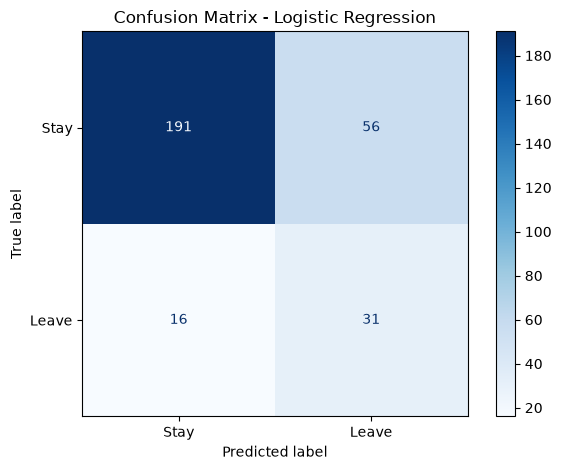

In [62]:
# Confusion Matrix For The Model Logisitic Regression

cm_logistic_regression= confusion_matrix(y_test, pred_logistic_regression)

display_logistic_regression=ConfusionMatrixDisplay(confusion_matrix=cm_logistic_regression, display_labels=["Stay","Leave"])

display_logistic_regression.plot(cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")

plt.tight_layout()
plt.savefig("../charts/confusion_matrix_logistic_regression.png")
plt.show()

In [63]:
# Evaluating The Random Forest Model

# Precision
precision_rf = precision_score(y_test, pred_random_forest)

# Recall
recall_rf = recall_score(y_test, pred_random_forest)

# F1 Score
f1_rf = f1_score(y_test, pred_random_forest)

# ROC-AUC Score
roc_auc_rf = roc_auc_score(y_test, pred_random_forest)

print("----- Random Forest -----")
print(f"Precision : {precision_rf:.4f}")
print(f"Recall    : {recall_rf:.4f}")
print(f"F1 Score  : {f1_rf:.4f}")
print(f"ROC-AUC   : {roc_auc_rf:.4f}")


----- Random Forest -----
Precision : 0.4516
Recall    : 0.2979
F1 Score  : 0.3590
ROC-AUC   : 0.6145


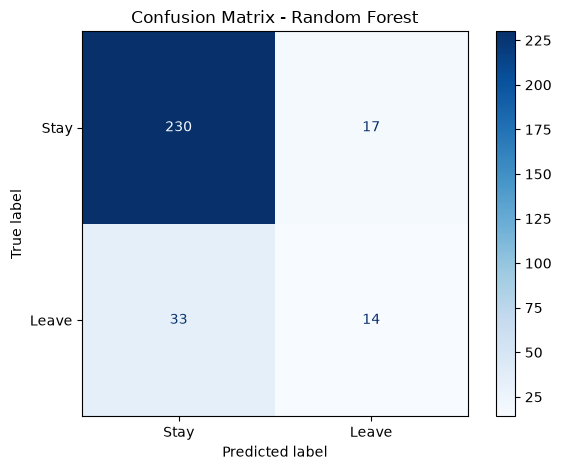

In [64]:
# Confusion Matrix For The Model Random Forest

cm_random_forest= confusion_matrix(y_test, pred_random_forest)

display_random_forest=ConfusionMatrixDisplay(confusion_matrix=cm_random_forest, display_labels=["Stay","Leave"])

display_random_forest.plot(cmap="Blues")

plt.title("Confusion Matrix - Random Forest")

plt.tight_layout()
plt.savefig("../charts/confusion_matrix_random_forest.png")
plt.show()

In [65]:
# Evaluating The Gradient Boosting Model

# Precision
precision_gb = precision_score(y_test, pred_gradient_boosting)

# Recall
recall_gb = recall_score(y_test, pred_gradient_boosting)

# F1 Score
f1_gb = f1_score(y_test, pred_gradient_boosting)

# ROC-AUC Score
roc_auc_gb = roc_auc_score(y_test, pred_gradient_boosting)

print("----- Gradient Boosting -----")
print(f"Precision : {precision_gb:.4f}")
print(f"Recall    : {recall_gb:.4f}")
print(f"F1 Score  : {f1_gb:.4f}")
print(f"ROC-AUC   : {roc_auc_gb:.4f}")


----- Gradient Boosting -----
Precision : 0.5882
Recall    : 0.2128
F1 Score  : 0.3125
ROC-AUC   : 0.5922


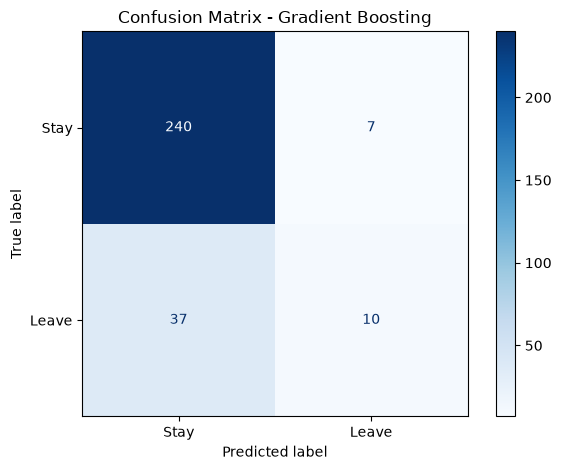

In [66]:
# Confusion Matrix For The Model Gradient Boosting

cm_gradient_boosting= confusion_matrix(y_test, pred_gradient_boosting)

display_gradient_boosting=ConfusionMatrixDisplay(confusion_matrix=cm_gradient_boosting, display_labels=["Stay","Leave"])

display_gradient_boosting.plot(cmap="Blues")

plt.title("Confusion Matrix - Gradient Boosting")

plt.tight_layout()
plt.savefig("../charts/confusion_matrix_random_forest.png")
plt.show()

In [67]:
# Models Comparison Tables 

comparison_table = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Precision": [
        precision_lr,
        precision_rf,
        precision_gb
    ],

    "Recall": [
        recall_lr,
        recall_rf,
        recall_gb
    ],

    "F1 Score": [
        f1_lr,
        f1_rf,
        f1_gb
    ],

    "ROC-AUC": [
        roc_auc_lr,
        roc_auc_rf,
        roc_auc_gb
    ]
})

comparison_table

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.356322,0.659574,0.462687,0.716427
1,Random Forest,0.451613,0.297872,0.358974,0.614523
2,Gradient Boosting,0.588235,0.212766,0.312500,0.592213


## Best Performing Model

Based on the evaluation metrics, **Logistic Regression** performed the best overall.

Although Gradient Boosting achieved the highest Precision, Logistic Regression obtained the highest Recall, F1-Score, and ROC-AUC Score.

Since the objective is to identify employees who are likely to leave the organization, Recall is particularly important because missing an employee who is about to leave can have a significant business impact.

Therefore, Logistic Regression was selected as the best-performing model for this employee attrition prediction task.

In [68]:
# Features Importance Of The Best Model

import pandas as pd

feature_coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model_logistic_regression.coef_[0]
})

feature_coefficients["Absolute Coefficient"] = (
    feature_coefficients["Coefficient"].abs()
)


# Ranking the top 10 most important features driving employee exit

feature_coefficients = feature_coefficients.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

print("factors matter most in predicting attrition and,\nranking the top 10 most important features driving employee exit\n")

top_10_features=feature_coefficients.head(10)
print(top_10_features)

factors matter most in predicting attrition and,
ranking the top 10 most important features driving employee exit

                             Feature  Coefficient  Absolute Coefficient
43                      OverTime_Yes     1.626169              1.626169
23  BusinessTravel_Travel_Frequently     1.596964              1.596964
34     JobRole_Laboratory Technician     1.571637              1.571637
40      JobRole_Sales Representative     1.264294              1.264294
37         JobRole_Research Director    -1.112054              1.112054
30              EducationField_Other    -1.020279              1.020279
24      BusinessTravel_Travel_Rarely     0.903722              0.903722
42              MaritalStatus_Single     0.864502              0.864502
33           JobRole_Human Resources     0.670991              0.670991
16                 TotalWorkingYears    -0.612480              0.612480


## Feature Importance Observation

The Logistic Regression model identifies the following features as the most influential in predicting employee attrition.

- Features with larger absolute coefficients have a stronger influence on the model's prediction.
- Positive coefficients increase the likelihood of employee attrition.
- Negative coefficients decrease the likelihood of employee attrition.
- These features represent the primary factors that the model uses to distinguish employees who are likely to leave from those who are likely to stay.

The ranked Top 10 features shown above provide valuable insights that can help HR teams focus on the most influential factors affecting employee retention.

# Task 6 – Visualization

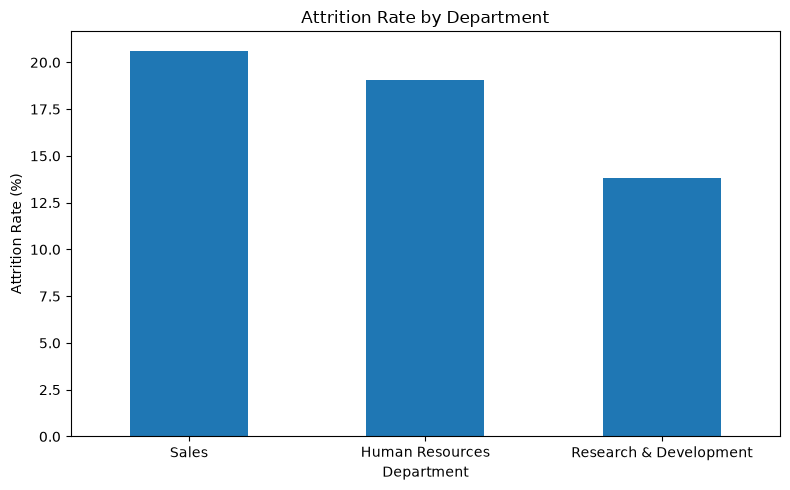

In [69]:
# Chart 1: Bar chart showing attrition rate by Department and Job Role

plt.figure(figsize=(8,5))
department_attrition.plot(kind="bar")
plt.title("Attrition Rate by Department")
plt.xlabel("Department")
plt.ylabel("Attrition Rate (%)")

plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig("../charts/attrition_by_department.png")
plt.show()

<Figure size 1000x600 with 0 Axes>

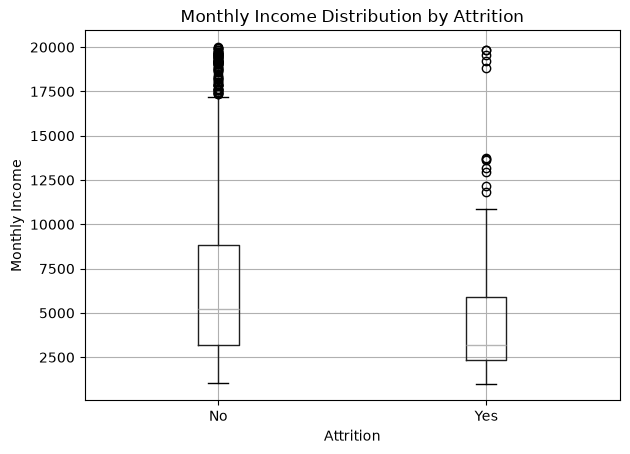

In [79]:
# Chart 2: Box plot comparing Monthly Income of employees who left vs stayed

plt.figure(figsize=(10,6))

df_eda.boxplot(column="MonthlyIncome", by="Attrition")

plt.title("Monthly Income Distribution by Attrition")
plt.suptitle("")  # Removes the default pandas title

plt.xlabel("Attrition")
plt.ylabel("Monthly Income")

plt.tight_layout()

plt.savefig("../charts/monthly_income_boxplot.png")

plt.show()

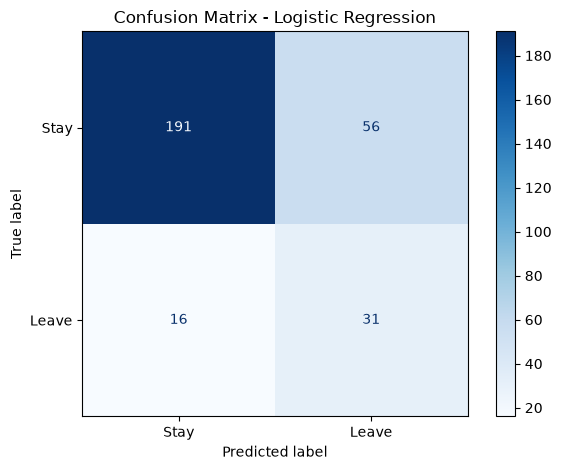

In [71]:
# Chart 3: Confusion Matrix heatmap for your best model

# Confusion Matrix For The Model Logisitic Regression


cm_logistic_regression = confusion_matrix(
    y_test,
    pred_logistic_regression
)

display_logistic_regression = ConfusionMatrixDisplay(
    confusion_matrix=cm_logistic_regression,
    display_labels=["Stay", "Leave"]
)

display_logistic_regression.plot(cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")

plt.tight_layout()

plt.savefig("../charts/confusion_matrix_logistic_regression.png")

plt.show()

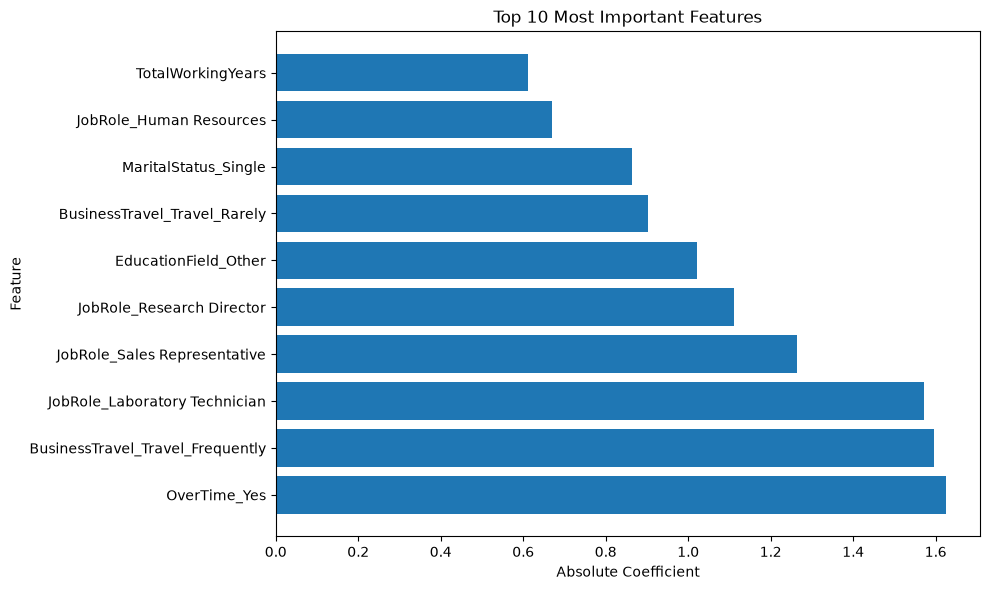

In [72]:
# Chart 4: Horizontal bar chart of Top 10 Feature Importances from your best model

plt.figure(figsize=(10,6))

plt.barh(
    top_10_features["Feature"],
    top_10_features["Absolute Coefficient"]
)

plt.title("Top 10 Most Important Features")
plt.xlabel("Absolute Coefficient")
plt.ylabel("Feature")


plt.tight_layout()

plt.savefig("../charts/top_10_feature_importance.png")

plt.show()

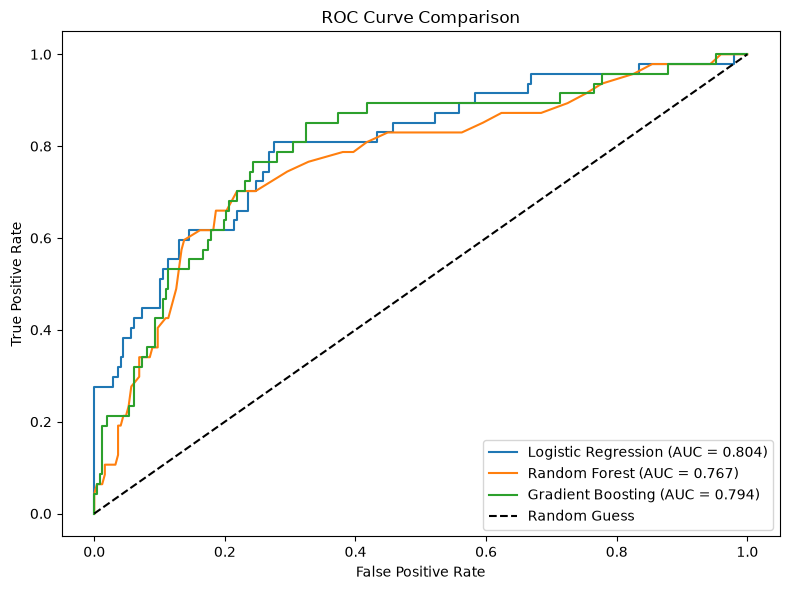

In [73]:
# Chart 5 - ROC Curve Comparison (Bonus)

'''
This ROC Curve compares the performance of Logistic Regression, Random Forest, 
and Gradient Boosting. 
A model with a larger Area Under the Curve (AUC) 
demonstrates better ability to distinguish between employees who leave and those who stay.
'''

from sklearn.metrics import roc_curve, auc

# Probability predictions
prob_lr= model_logistic_regression.predict_proba(X_test)[:,1]
prob_rf = model_random_forest.predict_proba(X_test)[:, 1]
prob_gb = model_gradient_boosting.predict_proba(X_test)[:, 1]

# ROC values
fpr_lr, tpr_lr, _ = roc_curve(y_test, prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, prob_rf)
fpr_gb, tpr_gb, _ = roc_curve(y_test, prob_gb)


# AUC
auc_lr = auc(fpr_lr, tpr_lr)
auc_rf = auc(fpr_rf, tpr_rf)
auc_gb = auc(fpr_gb, tpr_gb)

plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting (AUC = {auc_gb:.3f})")

plt.plot([0,1],[0,1],'k--', label="Random Guess")

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")


plt.legend()
plt.tight_layout()


plt.savefig("../charts/roc_curve_comparison.png")
plt.show()


# Task 7 - HR Insights & Business Recommendations

In [74]:
# Three factors most strongly predict that an employee will leave
print(feature_coefficients.head(3))

                             Feature  Coefficient  Absolute Coefficient
43                      OverTime_Yes     1.626169              1.626169
23  BusinessTravel_Travel_Frequently     1.596964              1.596964
34     JobRole_Laboratory Technician     1.571637              1.571637


## Step 7.1 - Strongest Predictors of Employee Attrition

Based on the Logistic Regression model, the three strongest predictors of employee attrition are:

1. **OverTime** – Employees who work overtime are more likely to leave the organization.
2. **Frequent Business Travel** – Employees who travel frequently have a higher likelihood of attrition.
3. **Laboratory Technician Job Role** – Employees in this role exhibit a comparatively higher risk of leaving.

These features had the highest absolute coefficient values in the Logistic Regression model, indicating that they have the greatest influence on attrition predictions.

In [75]:
# Department or job role should HR prioritize for retention efforts


# Department with highest attrition
highest_department = department_attrition.head(1)

# Job role with highest attrition
highest_job_role = job_role_attrition.head(1)

print("Department with highest attrition rate:")
print(highest_department)

print("\nJob role with highest attrition rate:")
print(highest_job_role)

Department with highest attrition rate:
Department
Sales    20.627803
Name: Attrition, dtype: float64

Job role with highest attrition rate:
JobRole
Sales Representative    39.759036
Name: Attrition, dtype: float64


## Step 7.2 - Department and Job Role to Prioritize

Based on the Exploratory Data Analysis (EDA), the **Sales** department recorded the highest attrition rate (**20.63%**), indicating that HR should prioritize retention efforts in this department.

Among all job roles, **Sales Representative** showed the highest attrition rate (**39.76%**). This suggests that employees in this role are at the greatest risk of leaving the organization.

Therefore, HR should focus on improving employee engagement, career development, and retention strategies for the **Sales department**, particularly **Sales Representatives**.

In [76]:
# Salary alone explain attrition or are there other stronger factors

print("\nTop 10 Most Important Features:")
print(feature_coefficients.head(10))


Top 10 Most Important Features:
                             Feature  Coefficient  Absolute Coefficient
43                      OverTime_Yes     1.626169              1.626169
23  BusinessTravel_Travel_Frequently     1.596964              1.596964
34     JobRole_Laboratory Technician     1.571637              1.571637
40      JobRole_Sales Representative     1.264294              1.264294
37         JobRole_Research Director    -1.112054              1.112054
30              EducationField_Other    -1.020279              1.020279
24      BusinessTravel_Travel_Rarely     0.903722              0.903722
42              MaritalStatus_Single     0.864502              0.864502
33           JobRole_Human Resources     0.670991              0.670991
16                 TotalWorkingYears    -0.612480              0.612480


## Step 7.3 - Does Salary Alone Explain Attrition?

The Exploratory Data Analysis (EDA) showed that employees in the lower salary range (₹0–₹5,000) experienced the highest attrition rate (21.76%), indicating that salary does influence employee turnover.

However, the Logistic Regression model identified **OverTime**, **Frequent Business Travel**, and **Laboratory Technician** as the strongest predictors of attrition. This indicates that while salary is an important factor, it is **not the only or the strongest factor** influencing employee attrition.

Therefore, employee attrition is driven by a combination of compensation, workload, travel frequency, and job role rather than salary alone.

In [77]:
# Concrete HR recommendations a company could implement based on your findings 
# (e.g., specific policy changes, who to target for a retention conversation)

print("Top 3 Predictors of Attrition:")
print(feature_coefficients.head(3))

Top 3 Predictors of Attrition:
                             Feature  Coefficient  Absolute Coefficient
43                      OverTime_Yes     1.626169              1.626169
23  BusinessTravel_Travel_Frequently     1.596964              1.596964
34     JobRole_Laboratory Technician     1.571637              1.571637


## Step 7.4 - HR Recommendations

### Recommendation 1: Listen to Employees and Resolve Genuine Concerns

The company should establish a culture where employees feel comfortable sharing their concerns with their managers and HR. Every genuine concern should be carefully reviewed instead of being ignored. If an issue can reasonably be resolved and benefits both the employee and the organization, efforts should be made to address it before the employee considers leaving.

---

### Recommendation 2: Promote Smart Work Alongside Hard Work

Hard work is important, but long-term productivity also depends on smart work. Employees who continuously work overtime without improving work efficiency may experience stress and burnout. The organization should encourage better planning, efficient workflows, automation where possible, and proper workload distribution so employees can maintain high performance without unnecessary pressure.

---

### Recommendation 3: Improve Work-Life Balance for High-Risk Employees

The analysis identified overtime as one of the strongest predictors of employee attrition. HR should regularly monitor employees with excessive overtime and frequent business travel, conduct periodic well-being check-ins, and provide support before these employees become disengaged or decide to leave.

---

### Recommendation 4: Prioritize Retention Over Replacement

Experienced employees possess valuable organizational knowledge, technical skills, and practical experience that are difficult to replace. Losing skilled employees means the company must invest additional time, effort, and financial resources into recruiting, onboarding, and training new employees. Therefore, retaining high-performing employees should be considered a long-term investment rather than a short-term expense.

---

### Recommendation 5: Use Data to Identify Employees at Risk

The trained machine learning model can be used as an early warning system to identify employees who may be at a higher risk of attrition. HR can use these insights to initiate conversations, understand employee concerns, and implement appropriate retention strategies before valuable employees decide to leave.

In [78]:
# Limitation does this model have that an HR team should be aware of before using it

print("Model Limitation:\n")

print("1. The model should be used as a decision-support tool, not a decision-making tool.")
print("2. Every employee has unique personal and professional circumstances that the model cannot fully understand.")
print("3. If an employee is predicted to be at risk of leaving, HR should communicate with the employee and understand their genuine concerns.")
print("4. If resolving those concerns benefits both the employee and the organization, HR should make reasonable efforts to address them.")
print("5. The model should be treated as an early warning system that helps HR identify employees who may require attention, while the final decision should always involve human judgment.")

Model Limitation:

1. The model should be used as a decision-support tool, not a decision-making tool.
2. Every employee has unique personal and professional circumstances that the model cannot fully understand.
3. If an employee is predicted to be at risk of leaving, HR should communicate with the employee and understand their genuine concerns.
4. If resolving those concerns benefits both the employee and the organization, HR should make reasonable efforts to address them.
5. The model should be treated as an early warning system that helps HR identify employees who may require attention, while the final decision should always involve human judgment.
